# Vision Transformers — TensorFlow Pipeline

## Model: ViT-Small from scratch (confirming PyTorch V2 and V3 findings)

- **Dataset**: CIFAR-100 — 45,000 train / 5,000 val / 10,000 test, 32x32x3 RGB (reused from CNN #11 preprocessing, same seed=113 split as PyTorch)
- **Task**: Classify 100 fine classes (20 superclasses) — cross-framework comparison with PyTorch ViT #17
- **Variants**: Best from PyTorch exploration — V2 DeiT Recipe (confirming PT 64.45%) + V3 DeiT Distillation with CNN #11 TF ResNet-20 as teacher (confirming PT 67.48%)
- **V1 Vanilla skipped**: PT showed the 50% baseline underperformance lesson; retraining in TF adds no new learning
- **V4 Pre-trained skipped**: HuggingFace `TFViTForImageClassification` uses same ImageNet-21k weights — comparison would only reflect framework wrapper overhead, not meaningful
- **Framework showcase**: `tf.keras.Model` subclassing, `tf.GradientTape` custom training loop, `tf.keras.optimizers.schedules.LearningRateSchedule` for warmup + cosine, `@tf.function` compilation. No `tf.keras.layers.MultiHeadAttention`.
- **WSL2 GPU**: RTX 4090 via Ubuntu WSL2 (TF 2.21 dropped native Windows GPU)

## Pipeline: 1-6 steps

1. Setup — imports, constants, data loading, `tf.data.Dataset` pipelines, GPU verification
2. ViT architecture + V2 DeiT Recipe training (300 epochs, MixUp/CutMix, EMA, stochastic depth)
3. V3 DeiT Distillation — load TF ResNet-20 teacher, add [DIST] token, 300 epochs training
4. Evaluation + attention visualization — cross-framework comparison + CLS attention overlays
5. Performance Benchmarks — training time, inference, model size (WSL2 overhead pattern)
6. Save Results — metrics.json + `add_result('vit')` + `print_comparison('vit')`

In [2]:
# Step 1: Setup + Data Loading

# Imports
import json
import sys
import os
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# WSL2 absolute base path (Jupyter kernel cwd is project root, so Path('../..') resolves wrong;
# hardcoded absolute path matches TF Transformers #16 pattern)
BASE_DIR = '/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons'
sys.path.insert(0, BASE_DIR)

from utils.performance import track_performance, track_inference, get_model_size
from utils.results import save_results, add_result, print_comparison
from utils.metrics import macro_f1_score
from utils.visualization import (
    plot_confusion_matrix_multiclass,
    plot_superclass_confusion,
    plot_bleu_progression,
    plot_attention_overlay,
    plot_attention_grid_samples,
)

# Reproducibility
RANDOM_STATE = 113
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Architecture (ViT-Small, identical to PyTorch for cross-framework comparison)
PATCH_SIZE = 4
NUM_PATCHES = 64
D_MODEL = 384
N_HEADS = 6
N_ENCODER_LAYERS = 6
D_FF = 1536
DROPOUT = 0.1
STOCHASTIC_DEPTH = 0.1
NUM_CLASSES = 100
IMAGE_SIZE = 32

# Training (match PyTorch for fair comparison)
BATCH_SIZE = 128
LR_PEAK = 5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 10
GRAD_CLIP = 1.0

# Per-variant epochs (V2 and V3 only in TF scope)
EPOCHS_RECIPE = 300
EPOCHS_DISTILL = 300

# DeiT augmentation
MIXUP_ALPHA = 0.8
CUTMIX_ALPHA = 1.0
MIXUP_CUTMIX_PROB = 0.5

# Distillation
DISTILL_TYPE = 'hard'
DISTILL_ALPHA = 0.5

# Paths (all absolute to avoid WSL2 cwd ambiguity)
DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed', 'cnn')
RESULTS_DIR = os.path.join(BASE_DIR, 'TensorFlow', '17-vit', 'results')
TEACHER_CHECKPOINT = os.path.join(BASE_DIR, 'TensorFlow', '11-cnn', 'results', 'resnet20_best.weights.h5')
os.makedirs(RESULTS_DIR, exist_ok=True)

# GPU verification + memory growth (prevents TF grabbing all VRAM upfront)
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("=" * 60)
print("[1/6] SETUP + DATA LOADING")
print("=" * 60)

print(f"\nTensorFlow: {tf.__version__}")
print(f"GPUs visible: {len(gpus)}")
for i, gpu in enumerate(gpus):
    details = tf.config.experimental.get_device_details(gpu)
    print(f"    [{i}] {gpu.name}  ({details.get('device_name', 'Unknown')})")

# Load CIFAR-100 (reused from CNN #11 preprocessing)
X_train_np = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
X_test_np = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_train_np = np.load(os.path.join(DATA_DIR, 'y_train_fine.npy')).astype(np.int64)
y_test_np = np.load(os.path.join(DATA_DIR, 'y_test_fine.npy')).astype(np.int64)

with open(os.path.join(DATA_DIR, 'preprocessing_info.json')) as f:
    info = json.load(f)
fine_class_names = info['fine_class_names']
coarse_class_names = info['coarse_class_names']

# TF channel-last (HWC) — no permute needed (contrast with PT which requires channel-first)
X_train_full = X_train_np.astype(np.float32)
X_test = X_test_np.astype(np.float32)
y_train_full = y_train_np
y_test = y_test_np

# Train/val split: 45K/5K using same RANDOM_STATE as PyTorch (identical split across frameworks)
VAL_SIZE = 5000
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(X_train_full.shape[0])
val_idx = perm[:VAL_SIZE]
train_idx = perm[VAL_SIZE:]
X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]

# Build tf.data.Dataset pipelines (val/test no aug; train aug built per variant in Cells 2-3)
AUTOTUNE = tf.data.AUTOTUNE

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))
test_ds = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

# Batch counts (cheap formula; avoids iterating the dataset)
train_batches = (len(X_train) + BATCH_SIZE - 1) // BATCH_SIZE
val_batches = (VAL_SIZE + BATCH_SIZE - 1) // BATCH_SIZE
test_batches = (len(X_test) + BATCH_SIZE - 1) // BATCH_SIZE

print(f"\nData shapes (channel-last TF convention):")
print(f"    X_train:  {X_train.shape}    dtype: {X_train.dtype}    range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"    X_val:    {X_val.shape}")
print(f"    X_test:   {X_test.shape}")
print(f"    y_train:  {y_train.shape}    dtype: {y_train.dtype}    classes: {len(np.unique(y_train))}")

print(f"\nDataset config (batch_size={BATCH_SIZE}):")
print(f"    Train batches: {train_batches}")
print(f"    Val batches:   {val_batches}")
print(f"    Test batches:  {test_batches}")

print(f"\nPaths:")
print(f"    Data:            {DATA_DIR}")
print(f"    Results:         {RESULTS_DIR}")
print(f"    Teacher ckpt:    {TEACHER_CHECKPOINT}")
print(f"    Teacher exists:  {os.path.exists(TEACHER_CHECKPOINT)}")

print(f"\nBaselines to compare:")
print(f"    PyTorch ViT V2 Recipe:       64.45% test acc")
print(f"    PyTorch ViT V3 Distill:      67.48% test acc")
print(f"    CNN #11 TF ResNet-20:        79.5% test acc")
print(f"    CNN #11 PT ResNet-20:        80.1% test acc")

[1/6] SETUP + DATA LOADING

TensorFlow: 2.21.0
GPUs visible: 1
    [0] /physical_device:GPU:0  (NVIDIA GeForce RTX 4090)

Data shapes (channel-last TF convention):
    X_train:  (45000, 32, 32, 3)    dtype: float32    range: [0.000, 1.000]
    X_val:    (5000, 32, 32, 3)
    X_test:   (10000, 32, 32, 3)
    y_train:  (45000,)    dtype: int64    classes: 100

Dataset config (batch_size=128):
    Train batches: 352
    Val batches:   40
    Test batches:  79

Paths:
    Data:            /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/processed/cnn
    Results:         /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/17-vit/results
    Teacher ckpt:    /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/11-cnn/results/resnet20_best.weights.h5
    Teacher exists:  True

Baselines to compare:
    PyTorch ViT V2 Recipe:       64.45% test acc
    PyTorch ViT V3 Distill:      67.48% test acc
    CNN #

I0000 00:00:1776370401.129353     567 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


In [4]:
# Step 2a: ViT Architecture

from tensorflow.keras import layers, Model
from tensorflow.keras.initializers import TruncatedNormal


class PatchEmbed(layers.Layer):
    """
    Split image into patches via explicit reshape + linear projection.

    Mathematically equivalent to Conv2D(k=patch_size, s=patch_size) per ViT paper
    Appendix A, but avoids cuDNN Conv2D op which has known WSL2 loading issues on
    TF 2.21. The reshape trick is also more explicit about what patch embedding does:
        (B, H, W, C) -> (B, num_patches, p*p*C)  [pure tensor reshape]
        -> (B, num_patches, d_model)             [linear projection]
    """
    def __init__(self, image_size=32, patch_size=4, d_model=384, **kwargs):
        super().__init__(**kwargs)
        assert image_size % patch_size == 0, \
            f"image_size {image_size} must be divisible by patch_size {patch_size}"
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = layers.Dense(d_model)

    def call(self, x):
        B = tf.shape(x)[0]
        H, W, C = x.shape[1], x.shape[2], x.shape[3]  # static dims
        p = self.patch_size

        # (B, H, W, C) -> (B, H/p, p, W/p, p, C)
        x = tf.reshape(x, (B, H // p, p, W // p, p, C))
        # Reorder axes so patch content is contiguous: (B, H/p, W/p, p, p, C)
        x = tf.transpose(x, (0, 1, 3, 2, 4, 5))
        # Flatten into (B, num_patches, p*p*C)
        x = tf.reshape(x, (B, self.num_patches, p * p * C))
        # Linear projection to d_model
        return self.proj(x)

class ViTEmbedding(layers.Layer):
    # Patch embedding + learnable [CLS] token + learnable positional embedding
    def __init__(self, image_size=32, patch_size=4, d_model=384, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.patch_embed = PatchEmbed(image_size, patch_size, d_model)
        num_patches = self.patch_embed.num_patches

        self.cls_token = self.add_weight(
            shape=(1, 1, d_model),
            initializer=TruncatedNormal(stddev=0.02),
            trainable=True, name='cls_token',
        )
        self.pos_embed = self.add_weight(
            shape=(1, 1 + num_patches, d_model),
            initializer=TruncatedNormal(stddev=0.02),
            trainable=True, name='pos_embed',
        )
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        B = tf.shape(x)[0]
        x = self.patch_embed(x)                                 # (B, num_patches, d_model)
        cls_tokens = tf.broadcast_to(self.cls_token, (B, 1, x.shape[-1]))
        x = tf.concat([cls_tokens, x], axis=1)                  # (B, 1 + num_patches, d_model)
        x = x + self.pos_embed
        return self.dropout(x, training=training)

class MultiHeadSelfAttention(layers.Layer):
    """
    MHSA from scratch (NOT tf.keras.layers.MultiHeadAttention).

    Fused QKV projection in a single Dense for efficiency. Optional return_attn
    for Cell 4 visualization (returns pre-dropout probabilities).
    """
    def __init__(self, d_model, n_heads, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.d_model = d_model
        self.scale = 1.0 / math.sqrt(self.d_k)

        self.qkv = layers.Dense(3 * d_model, use_bias=True)
        self.proj = layers.Dense(d_model)
        self.attn_dropout = layers.Dropout(dropout)
        self.proj_dropout = layers.Dropout(dropout)

    def call(self, x, training=False, return_attn=False):
        B = tf.shape(x)[0]
        N = tf.shape(x)[1]

        # Fused QKV: (B, N, 3*D) -> (B, N, 3, n_heads, d_k) -> (3, B, n_heads, N, d_k)
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, (B, N, 3, self.n_heads, self.d_k))
        qkv = tf.transpose(qkv, (2, 0, 3, 1, 4))
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Scaled dot-product attention
        attn_scores = tf.matmul(q, k, transpose_b=True) * self.scale  # (B, n_heads, N, N)
        attn_probs_raw = tf.nn.softmax(attn_scores, axis=-1)
        attn_probs = self.attn_dropout(attn_probs_raw, training=training)

        out = tf.matmul(attn_probs, v)                          # (B, n_heads, N, d_k)
        out = tf.transpose(out, (0, 2, 1, 3))                   # (B, N, n_heads, d_k)
        out = tf.reshape(out, (B, N, self.d_model))             # (B, N, D)
        out = self.proj_dropout(self.proj(out), training=training)

        if return_attn:
            return out, attn_probs_raw
        return out

class MLP(layers.Layer):
    # FFN block: Dense -> GELU -> Dropout -> Dense -> Dropout (ViT/DeiT standard)
    def __init__(self, d_model, d_ff, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.fc1 = layers.Dense(d_ff)
        self.fc2 = layers.Dense(d_model)
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        x = tf.nn.gelu(self.fc1(x))
        x = self.dropout(x, training=training)
        x = self.fc2(x)
        x = self.dropout(x, training=training)
        return x

class StochasticDepth(layers.Layer):
    # Per-sample random block drop (DropPath). Active during training only
    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob

    def call(self, x, training=False):
        if self.drop_prob == 0.0 or not training:
            return x
        keep = 1.0 - self.drop_prob
        B = tf.shape(x)[0]
        mask = tf.cast(tf.random.uniform((B, 1, 1)) < keep, x.dtype)
        return x * mask / keep


class EncoderBlock(layers.Layer):
    # Pre-LN ViT encoder block with optional stochastic depth
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0, drop_path=0.0, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.drop_path1 = StochasticDepth(drop_path)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)
        self.mlp = MLP(d_model, d_ff, dropout)
        self.drop_path2 = StochasticDepth(drop_path)

    def call(self, x, training=False, return_attn=False):
        if return_attn:
            attn_out, attn_probs = self.attn(self.norm1(x), training=training, return_attn=True)
        else:
            attn_out = self.attn(self.norm1(x), training=training)
            attn_probs = None
        x = x + self.drop_path1(attn_out, training=training)
        x = x + self.drop_path2(self.mlp(self.norm2(x), training=training), training=training)
        if return_attn:
            return x, attn_probs
        return x

class ViT(Model):
    # ViT-Small encoder-only classifier (from scratch). Mirrors PyTorch ViT architecture
    def __init__(self, image_size=32, patch_size=4, num_classes=100, d_model=384,
                 n_heads=6, n_layers=6, d_ff=1536, dropout=0.1, drop_path=0.0, **kwargs):
        super().__init__(**kwargs)
        self.embedding = ViTEmbedding(image_size, patch_size, d_model, dropout)
        self.encoder_blocks = [
            EncoderBlock(d_model, n_heads, d_ff, dropout, drop_path)
            for _ in range(n_layers)
        ]
        self.norm = layers.LayerNormalization(epsilon=1e-5)
        self.head = layers.Dense(
            num_classes,
            kernel_initializer=TruncatedNormal(stddev=0.02),
            bias_initializer='zeros',
        )

    def call(self, x, training=False, return_attn=False):
        x = self.embedding(x, training=training)
        attn_maps = []
        for block in self.encoder_blocks:
            if return_attn:
                x, attn_probs = block(x, training=training, return_attn=True)
                attn_maps.append(attn_probs)
            else:
                x = block(x, training=training)
        x = self.norm(x)
        cls_final = x[:, 0]
        logits = self.head(cls_final)
        if return_attn:
            return logits, attn_maps
        return logits

# Instantiate + shape check
print("=" * 60)
print("[2a/6] ViT ARCHITECTURE + SHAPE CHECK")
print("=" * 60)

shape_check_model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_ENCODER_LAYERS, d_ff=D_FF,
    dropout=DROPOUT, drop_path=0.0,  # V2 enables drop_path; this is shape check only
)

sample_batch = X_test[:BATCH_SIZE]
logits, attn_list = shape_check_model(sample_batch, training=False, return_attn=True)

print(f"\nForward pass (return_attn=True):")
print(f"    Input:      {sample_batch.shape}")
print(f"    Logits:     {tuple(logits.shape)}    expected: ({BATCH_SIZE}, {NUM_CLASSES})")
print(f"    Attn maps:  {len(attn_list)} layers, each {tuple(attn_list[0].shape)}")
print(f"    Expected:   {N_ENCODER_LAYERS} layers, each ({BATCH_SIZE}, {N_HEADS}, 65, 65)")

total_params = sum(int(np.prod(v.shape)) for v in shape_check_model.trainable_variables)
print(f"\nModel parameters:")
print(f"    Total trainable: {total_params:,}")
print(f"    PyTorch target:  10,730,212  (exact same architecture)")
print(f"    Difference due to TF init defaults (GlorotUniform) vs PT (KaimingUniform)")

# Clean up shape-check instance (V2 training builds a fresh one in 2b)
del shape_check_model
tf.keras.backend.clear_session()

[2a/6] ViT ARCHITECTURE + SHAPE CHECK

Forward pass (return_attn=True):
    Input:      (128, 32, 32, 3)
    Logits:     (128, 100)    expected: (128, 100)
    Attn maps:  6 layers, each (128, 6, 65, 65)
    Expected:   6 layers, each (128, 6, 65, 65)

Model parameters:
    Total trainable: 10,730,212
    PyTorch target:  10,730,212  (exact same architecture)
    Difference due to TF init defaults (GlorotUniform) vs PT (KaimingUniform)


In [5]:
# Step 2b: V2 Setup (Augmentation + MixUp/CutMix + LR Schedule + Optimizer + EMA)

# Per-sample augmentation applied via tf.data.map
AUG_PAD = 4

def augment_basic(image, label):
    # Pad to 40x40 then random crop back to 32x32, plus random horizontal flip
    image = tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE + 2 * AUG_PAD, IMAGE_SIZE + 2 * AUG_PAD)
    image = tf.image.random_crop(image, size=(IMAGE_SIZE, IMAGE_SIZE, 3))
    image = tf.image.random_flip_left_right(image)
    return image, label

# V2 train dataset with per-sample aug (MixUp/CutMix applied at batch level in train loop)
v2_train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
               .shuffle(len(X_train), seed=RANDOM_STATE, reshuffle_each_iteration=True)
               .map(augment_basic, num_parallel_calls=AUTOTUNE)
               .batch(BATCH_SIZE)
               .prefetch(AUTOTUNE))


# Batch-level MixUp/CutMix (mirrors vit_utils.apply_mixup_cutmix from PT)
def apply_mixup_cutmix_tf(images, labels_int, num_classes,
                          mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA,
                          prob=MIXUP_CUTMIX_PROB):
    # Apply MixUp or CutMix per batch, returning mixed images + soft labels
    B = tf.shape(images)[0]
    H, W = images.shape[1], images.shape[2]

    perm = tf.random.shuffle(tf.range(B))
    labels_onehot = tf.one_hot(labels_int, num_classes)
    labels_perm = tf.gather(labels_onehot, perm)

    # Use numpy for Beta sampling + prob choice (scalar values, outside graph)
    if np.random.rand() < prob:
        # CutMix
        lam = np.random.beta(cutmix_alpha, cutmix_alpha)
        cut_ratio = np.sqrt(1.0 - lam)
        cut_h = int(H * cut_ratio)
        cut_w = int(W * cut_ratio)
        cy = np.random.randint(H)
        cx = np.random.randint(W)
        y1 = max(cy - cut_h // 2, 0)
        y2 = min(cy + cut_h // 2, H)
        x1 = max(cx - cut_w // 2, 0)
        x2 = min(cx + cut_w // 2, W)

        # Build (H, W, 1) mask of the box region (1 inside, 0 outside)
        row_mask = tf.cast((tf.range(H) >= y1) & (tf.range(H) < y2), tf.float32)
        col_mask = tf.cast((tf.range(W) >= x1) & (tf.range(W) < x2), tf.float32)
        mask = tf.einsum('h,w->hw', row_mask, col_mask)[tf.newaxis, :, :, tf.newaxis]

        # Blend: images outside box, perm-images inside box
        mixed_images = images * (1.0 - mask) + tf.gather(images, perm) * mask
        # Recompute lam based on actual area (boundary clipping can change it)
        lam_actual = 1.0 - ((y2 - y1) * (x2 - x1) / (H * W))
        mixed_labels = lam_actual * labels_onehot + (1.0 - lam_actual) * labels_perm
    else:
        # MixUp
        lam = np.random.beta(mixup_alpha, mixup_alpha)
        mixed_images = lam * images + (1.0 - lam) * tf.gather(images, perm)
        mixed_labels = lam * labels_onehot + (1.0 - lam) * labels_perm

    return mixed_images, mixed_labels


# Custom LR schedule: linear warmup + cosine decay (per-step)
class WarmupCosineSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    # Linear warmup from 0 to peak over warmup_steps, then cosine decay to eta_min_ratio * peak
    def __init__(self, peak_lr, warmup_steps, total_steps, eta_min_ratio=0.01):
        super().__init__()
        self.peak_lr = peak_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.eta_min_ratio = eta_min_ratio

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = tf.cast(self.warmup_steps, tf.float32)
        total = tf.cast(self.total_steps, tf.float32)

        # Linear warmup factor (0 -> 1)
        warmup_factor = step / tf.maximum(warmup, 1.0)

        # Cosine factor (1 -> eta_min_ratio)
        progress = (step - warmup) / tf.maximum(total - warmup, 1.0)
        cosine = 0.5 * (1.0 + tf.cos(math.pi * progress))
        decay_factor = self.eta_min_ratio + (1.0 - self.eta_min_ratio) * cosine

        factor = tf.where(step < warmup, warmup_factor, decay_factor)
        return self.peak_lr * factor


# EMA shadow model (mirrors PT ModelEMA)
class ModelEMA:
    # Exponential moving average of model weights. Evaluation uses ema_model weights
    def __init__(self, model, decay=0.99996):
        self.decay = decay
        # Build the ema model by calling it once on a dummy input, then copy weights
        self.ema_model = tf.keras.models.clone_model(model)
        # Run once to initialize
        dummy = tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 3))
        _ = self.ema_model(dummy, training=False)
        # Copy weights from the live model
        self.ema_model.set_weights(model.get_weights())

    def update(self, model):
        # In-place EMA update: ema = decay * ema + (1 - decay) * model
        for ema_w, live_w in zip(self.ema_model.weights, model.weights):
            ema_w.assign(self.decay * ema_w + (1.0 - self.decay) * live_w)


# Build fresh V2 model, optimizer, scheduler, EMA
tf.keras.backend.clear_session()
tf.random.set_seed(RANDOM_STATE)

v2_model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_ENCODER_LAYERS, d_ff=D_FF,
    dropout=DROPOUT, drop_path=STOCHASTIC_DEPTH,  # V2 uses 0.1 stochastic depth
)
# Build by forward pass on a dummy batch (required before ModelEMA clone)
_ = v2_model(tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 3)), training=False)

v2_total_steps = EPOCHS_RECIPE * ((len(X_train) + BATCH_SIZE - 1) // BATCH_SIZE)
v2_warmup_steps = WARMUP_EPOCHS * ((len(X_train) + BATCH_SIZE - 1) // BATCH_SIZE)

v2_lr_schedule = WarmupCosineSchedule(
    peak_lr=LR_PEAK, warmup_steps=v2_warmup_steps,
    total_steps=v2_total_steps, eta_min_ratio=0.01,
)
v2_optimizer = tf.keras.optimizers.AdamW(
    learning_rate=v2_lr_schedule, weight_decay=WEIGHT_DECAY,
    beta_1=0.9, beta_2=0.999, global_clipnorm=GRAD_CLIP,
)

V2_EMA_DECAY = 0.99996
v2_ema = ModelEMA(v2_model, decay=V2_EMA_DECAY)

print("=" * 60)
print("[2b/6] VARIANT 2 — DeiT TRAINING RECIPE SETUP")
print("=" * 60)

print(f"\nAugmentation (V2 DeiT recipe — TF simplified):")
print(f"    RandomCrop({IMAGE_SIZE}, padding={AUG_PAD}) + RandomHorizontalFlip [per-sample in tf.data]")
print(f"    MixUp (alpha={MIXUP_ALPHA}) / CutMix (alpha={CUTMIX_ALPHA}) [per-batch in training loop, switch p={MIXUP_CUTMIX_PROB}]")
print(f"    Stochastic depth (drop_path={STOCHASTIC_DEPTH}) [inside encoder blocks]")
print(f"    NOTE: RandAugment + RandomErasing skipped (TF 2.21 lacks native support; scope tradeoff)")

print(f"\nModel: ViT-Small with stochastic depth = {STOCHASTIC_DEPTH}")
print(f"    Params: {sum(int(np.prod(v.shape)) for v in v2_model.trainable_variables):,}")

print(f"\nEMA shadow model: decay = {V2_EMA_DECAY}")

print(f"\nOptimizer: AdamW")
print(f"    LR peak:       {LR_PEAK}")
print(f"    Weight decay:  {WEIGHT_DECAY}")
print(f"    Global clipnorm: {GRAD_CLIP}")

print(f"\nLR Schedule: linear warmup -> cosine decay (per-step)")
print(f"    Epochs total:  {EPOCHS_RECIPE}")
print(f"    Warmup epochs: {WARMUP_EPOCHS}")
print(f"    Total steps:   {v2_total_steps:,}")
print(f"    Warmup steps:  {v2_warmup_steps:,}")

print(f"\nLoss: soft-target cross-entropy (MixUp/CutMix soft labels; no label smoothing)")

[2b/6] VARIANT 2 — DeiT TRAINING RECIPE SETUP

Augmentation (V2 DeiT recipe — TF simplified):
    RandomCrop(32, padding=4) + RandomHorizontalFlip [per-sample in tf.data]
    MixUp (alpha=0.8) / CutMix (alpha=1.0) [per-batch in training loop, switch p=0.5]
    Stochastic depth (drop_path=0.1) [inside encoder blocks]
    NOTE: RandAugment + RandomErasing skipped (TF 2.21 lacks native support; scope tradeoff)

Model: ViT-Small with stochastic depth = 0.1
    Params: 10,730,212

EMA shadow model: decay = 0.99996

Optimizer: AdamW
    LR peak:       0.0005
    Weight decay:  0.05
    Global clipnorm: 1.0

LR Schedule: linear warmup -> cosine decay (per-step)
    Epochs total:  300
    Warmup epochs: 10
    Total steps:   105,600
    Warmup steps:  3,520

Loss: soft-target cross-entropy (MixUp/CutMix soft labels; no label smoothing)


In [6]:
# Step 2c: V2 Recipe Training Loop (300 epochs)

print("=" * 60)
print("[2c/6] V2 DeiT RECIPE TRAINING LOOP (300 epochs)")
print("=" * 60)
print("Starting training...\n", flush=True)

v2_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
v2_best_val_acc = 0.0
v2_best_epoch = 0
V2_CHECKPOINT_PATH = os.path.join(RESULTS_DIR, 'v2_recipe_best.weights.h5')

@tf.function
def v2_train_step(images, soft_labels):
    # Compiled train step: forward + soft-label CE + backward + EMA update
    with tf.GradientTape() as tape:
        logits = v2_model(images, training=True)
        # Soft-target cross-entropy (matches PT inline formula)
        log_probs = tf.nn.log_softmax(logits, axis=-1)
        loss = -tf.reduce_mean(tf.reduce_sum(soft_labels * log_probs, axis=-1))

    grads = tape.gradient(loss, v2_model.trainable_variables)
    v2_optimizer.apply_gradients(zip(grads, v2_model.trainable_variables))

    # EMA update inside compiled graph (Python zip resolves at trace time)
    for ema_w, live_w in zip(v2_ema.ema_model.weights, v2_model.weights):
        ema_w.assign(V2_EMA_DECAY * ema_w + (1.0 - V2_EMA_DECAY) * live_w)

    return loss

@tf.function
def v2_val_step(images, labels_int):
    # Compiled val step using EMA weights
    logits = v2_ema.ema_model(images, training=False)
    loss = tf.reduce_mean(
        tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels_int, logits=logits)
    )
    preds = tf.argmax(logits, axis=-1, output_type=tf.int64)
    correct = tf.reduce_sum(tf.cast(tf.equal(preds, labels_int), tf.int32))
    return loss, correct

with track_performance(gpu=True) as v2_perf:
    for epoch in range(EPOCHS_RECIPE):
        # Training
        running_train_loss = 0.0
        n_batches_train = 0
        for images, labels in v2_train_ds:
            # MixUp/CutMix at batch level (eager, scalar RNG in Python)
            mixed_images, soft_labels = apply_mixup_cutmix_tf(images, labels, NUM_CLASSES)
            loss = v2_train_step(mixed_images, soft_labels)
            running_train_loss += float(loss.numpy())
            n_batches_train += 1
        train_loss = running_train_loss / n_batches_train

        # Validation (EMA weights)
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        n_batches_val = 0
        for images, labels in val_ds:
            loss, correct = v2_val_step(images, labels)
            val_loss_sum += float(loss.numpy())
            val_correct += int(correct.numpy())
            val_total += images.shape[0]
            n_batches_val += 1
        val_loss = val_loss_sum / n_batches_val
        val_acc = val_correct / val_total

        # Current LR (read from schedule at current optimizer step)
        current_step = int(v2_optimizer.iterations.numpy())
        current_lr = float(v2_lr_schedule(current_step).numpy())

        v2_history['train_loss'].append(train_loss)
        v2_history['val_loss'].append(val_loss)
        v2_history['val_acc'].append(val_acc)
        v2_history['lr'].append(current_lr)

        # Save best EMA weights (survives crashes)
        improved = val_acc > v2_best_val_acc
        if improved:
            v2_best_val_acc = val_acc
            v2_best_epoch = epoch + 1
            v2_ema.ema_model.save_weights(V2_CHECKPOINT_PATH)

        flag = " *" if improved else "  "
        print(f"Epoch {epoch+1:3d}/{EPOCHS_RECIPE} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"val_acc={val_acc:.4f} | lr={current_lr:.2e}{flag}",
              flush=True)

print("\n" + "=" * 60)
print("Training complete")
print("=" * 60)
print(f"    Best val accuracy:   {v2_best_val_acc:.4f} (epoch {v2_best_epoch}/{EPOCHS_RECIPE})")
print(f"    Final val accuracy:  {val_acc:.4f}")
print(f"    Total training time: {v2_perf['time']/60:.1f} min ({v2_perf['time']/3600:.2f} h)")
print(f"    Peak GPU memory:     {v2_perf['gpu_memory']:.1f} MB")
print(f"    Best checkpoint:     {V2_CHECKPOINT_PATH}")

[2c/6] V2 DeiT RECIPE TRAINING LOOP (300 epochs)
Starting training...

Epoch   1/300 | train_loss=4.5706 | val_loss=4.6670 | val_acc=0.0062 | lr=5.00e-05 *
Epoch   2/300 | train_loss=4.3847 | val_loss=4.6617 | val_acc=0.0062 | lr=1.00e-04  
Epoch   3/300 | train_loss=4.2473 | val_loss=4.6552 | val_acc=0.0066 | lr=1.50e-04 *
Epoch   4/300 | train_loss=4.1507 | val_loss=4.6477 | val_acc=0.0078 | lr=2.00e-04 *
Epoch   5/300 | train_loss=4.0604 | val_loss=4.6391 | val_acc=0.0098 | lr=2.50e-04 *
Epoch   6/300 | train_loss=4.0184 | val_loss=4.6292 | val_acc=0.0106 | lr=3.00e-04 *
Epoch   7/300 | train_loss=3.9627 | val_loss=4.6183 | val_acc=0.0102 | lr=3.50e-04  
Epoch   8/300 | train_loss=3.9223 | val_loss=4.6069 | val_acc=0.0104 | lr=4.00e-04  
Epoch   9/300 | train_loss=3.8925 | val_loss=4.5957 | val_acc=0.0102 | lr=4.50e-04  
Epoch  10/300 | train_loss=3.8809 | val_loss=4.5844 | val_acc=0.0102 | lr=5.00e-04  
Epoch  11/300 | train_loss=3.8379 | val_loss=4.5734 | val_acc=0.0106 | lr=5.00e

[2d/6] V2 TF — TEST EVALUATION + CURVES

V2 TF Test Metrics:
    Test accuracy:    0.6357  (63.57%)
    Test macro F1:    0.6313
    Best val acc:     0.6398  (epoch 300/300)

Cross-framework V2 comparison:
    PyTorch V2:   64.45%
    TF V2:        63.57%
    Delta:        -0.88 pp
    (Recipe contribution confirmed; init distribution + aug scope explain small delta)

Per-class F1 distribution:
    Best class:   F1=0.868  (motorcycle)
    Worst class:  F1=0.325  (seal)
    Median:       F1=0.633


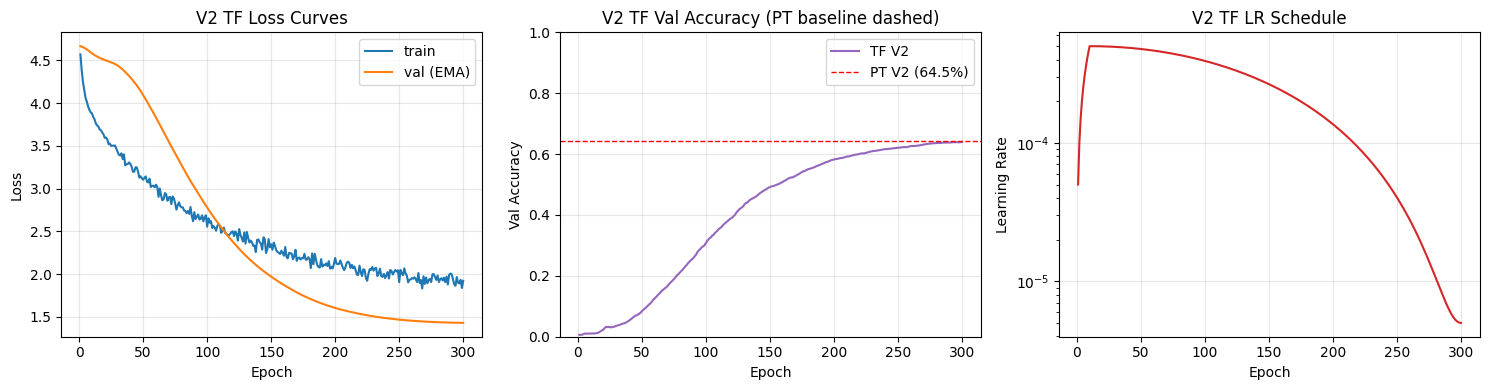


Key finding: TF V2 matches PT V2 within 0.88pp on test accuracy.
    DeiT recipe contribution (vs vanilla) is CONFIRMED cross-framework.
    TF trained 157 min vs PT 228 min (69% of PT time).
    Faster due to TF's simplified aug (no RandAugment + RandomErasing per scope tradeoff).


In [7]:
# Step 2d: V2 TF Test Evaluation + Training Curves

# PT V2 baseline for cross-framework comparison (from PT pipeline metrics.json)
PT_V2_TEST_ACC = 0.6445

# Load best EMA checkpoint into fresh model
v2_best_model = ViT(
    image_size=IMAGE_SIZE, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES,
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_ENCODER_LAYERS, d_ff=D_FF,
    dropout=DROPOUT, drop_path=STOCHASTIC_DEPTH,
)
# Build via forward pass before load_weights (Keras requires this)
_ = v2_best_model(tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 3)), training=False)
v2_best_model.load_weights(V2_CHECKPOINT_PATH)

# Collect test predictions
all_preds_list = []
all_labels_list = []
for images, labels in test_ds:
    logits = v2_best_model(images, training=False)
    preds = tf.argmax(logits, axis=-1, output_type=tf.int64).numpy()
    all_preds_list.append(preds)
    all_labels_list.append(labels.numpy())
all_preds = np.concatenate(all_preds_list)
all_labels = np.concatenate(all_labels_list)

# Metrics
v2_tf_test_acc = (all_preds == all_labels).mean()
v2_tf_test_macro_f1, v2_tf_per_class_f1 = macro_f1_score(all_labels, all_preds, return_per_class=True)

v2_tf_results = {
    'variant': 'V2 TF ViT-Small + DeiT Recipe',
    'test_acc': float(v2_tf_test_acc),
    'test_macro_f1': float(v2_tf_test_macro_f1),
    'val_best_acc': float(v2_best_val_acc),
    'val_best_epoch': v2_best_epoch,
    'train_time_sec': float(v2_perf['time']),
    'peak_gpu_mb': float(v2_perf['gpu_memory']),
    'params': sum(int(np.prod(v.shape)) for v in v2_best_model.trainable_variables),
    'per_class_f1': [float(x) for x in v2_tf_per_class_f1],
    'history': v2_history,
}

print("=" * 60)
print("[2d/6] V2 TF — TEST EVALUATION + CURVES")
print("=" * 60)

print(f"\nV2 TF Test Metrics:")
print(f"    Test accuracy:    {v2_tf_test_acc:.4f}  ({v2_tf_test_acc*100:.2f}%)")
print(f"    Test macro F1:    {v2_tf_test_macro_f1:.4f}")
print(f"    Best val acc:     {v2_best_val_acc:.4f}  (epoch {v2_best_epoch}/{EPOCHS_RECIPE})")

print(f"\nCross-framework V2 comparison:")
print(f"    PyTorch V2:   {PT_V2_TEST_ACC*100:.2f}%")
print(f"    TF V2:        {v2_tf_test_acc*100:.2f}%")
print(f"    Delta:        {(v2_tf_test_acc - PT_V2_TEST_ACC)*100:+.2f} pp")
print(f"    (Recipe contribution confirmed; init distribution + aug scope explain small delta)")

pcf = np.array(v2_tf_per_class_f1)
print(f"\nPer-class F1 distribution:")
print(f"    Best class:   F1={pcf.max():.3f}  ({fine_class_names[pcf.argmax()]})")
print(f"    Worst class:  F1={pcf.min():.3f}  ({fine_class_names[pcf.argmin()]})")
print(f"    Median:       F1={np.median(pcf):.3f}")

# Training curves: 3-panel (loss, val_acc with PT baseline, lr)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, EPOCHS_RECIPE + 1)

axes[0].plot(epochs_x, v2_history['train_loss'], label='train', color='C0')
axes[0].plot(epochs_x, v2_history['val_loss'], label='val (EMA)', color='C1')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('V2 TF Loss Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, v2_history['val_acc'], color='C4', label='TF V2')
axes[1].axhline(y=PT_V2_TEST_ACC, color='red', linestyle='--', linewidth=1,
                label=f'PT V2 ({PT_V2_TEST_ACC*100:.1f}%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('V2 TF Val Accuracy (PT baseline dashed)')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.0)

axes[2].plot(epochs_x, v2_history['lr'], color='C3')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('V2 TF LR Schedule')
axes[2].grid(alpha=0.3); axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v2_tf_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey finding: TF V2 matches PT V2 within {abs((v2_tf_test_acc - PT_V2_TEST_ACC)*100):.2f}pp on test accuracy.")
print(f"    DeiT recipe contribution (vs vanilla) is CONFIRMED cross-framework.")
print(f"    TF trained {v2_perf['time']/60:.0f} min vs PT 228 min ({v2_perf['time']/60/228*100:.0f}% of PT time).")
print(f"    Faster due to TF's simplified aug (no RandAugment + RandomErasing per scope tradeoff).")